In [226]:
import sympy as sp
import numpy as np

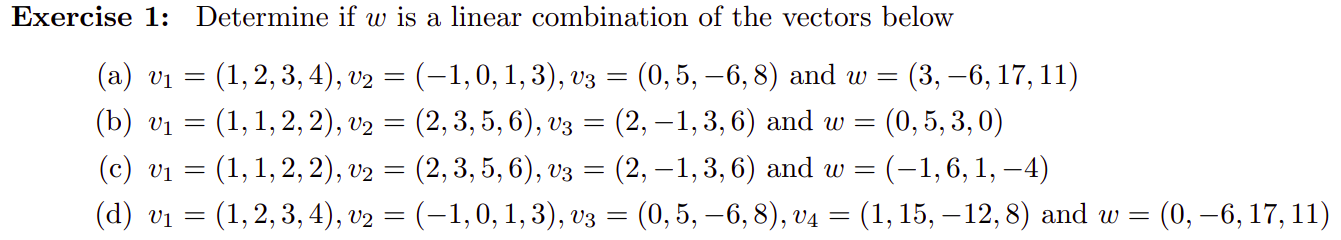

In [227]:
# Ham kiem tra doc lap tuyen tinh 
def is_linear_combination(A,w):
    A_ = np.column_stack((A, w))
    R, pivot_index = sp.Matrix(A_).rref()
    return pivot_index[-1] < A_.shape[1]-1

In [228]:
v1 = np.array([1,2,3,4])
v2 = np.array([-1,0,1,3])
v3 = np.array([0,5,-6,8])
w = np.array([3,-6,17,11])
C = np.column_stack((v1,v2,v3))
print(f"Câu (a): {is_linear_combination(C, w)}")
v1 = np.array([1, 1, 2, 2])
v2 = np.array([2, 3, 5, 6])
v3 = np.array([2, -1, 3, 6])
w = np.array([0, 5, 3, 0])
C = np.column_stack((v1, v2, v3))
print(f"Câu (b): {is_linear_combination(C, w)}")
v1 = np.array([1, 1, 2, 2])
v2 = np.array([2, 3, 5, 6])
v3 = np.array([2, -1, 3, 6])
w = np.array([-1, 6, 1, -4])
C = np.column_stack((v1, v2, v3))
print(f"Câu (c): {is_linear_combination(C, w)}")
v1 = np.array([1, 2, 3, 4])
v2 = np.array([-1, 0, 1, 3])
v3 = np.array([0, 5, -6, 8])
v4 = np.array([1, 15, -12, 8])
w = np.array([0, -6, 17, 11])
C = np.column_stack((v1, v2, v3, v4))
print(f"Câu (d): {is_linear_combination(C, w)}")

Câu (a): False
Câu (b): False
Câu (c): True
Câu (d): True


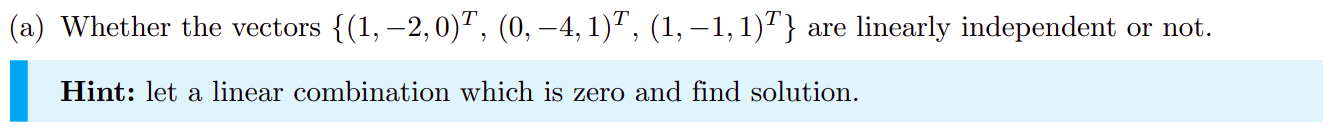

In [229]:
def is_linear_independent(A):
    R, pivot_index = sp.Matrix(A).rref()
    return len(pivot_index) == len(A.T)


In [230]:
v_a1 = [1, -2, 0]
v_a2 = [0, -4, 1]
v_a3 = [1, -1, 1]
C = np.column_stack((v_a1, v_a2,v_a3))
print(f"Câu (a): {is_linear_independent(C)}")


Câu (a): True


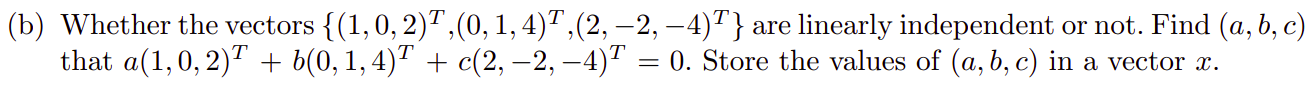

In [231]:
v_b1 = [1, 0, 2]
v_b2 = [0, 1, 4]
v_b3 = [2, -2, -4]
C = np.column_stack((v_b1, v_b2,v_b3))
def Ex2b(C):
    C_sp = sp.Matrix(C)
    R, pivots = C_sp.rref()

    n = C.shape[1]  
    x = np.zeros(n)

    pivots = list(pivots)
    free_vars = [j for j in range(n) if j not in pivots]
    if len(free_vars) == 0:
        return x  # vector 0
    free_var = free_vars[0]
    x[free_var] = 1
    for i in reversed(range(len(pivots))):
        pivot_col = pivots[i]
        s = 0
        for j in range(pivot_col + 1, n):
            s += float(R[i, j]) * x[j]
        x[pivot_col] = -s
    return x
x = Ex2b(C)
print("x =", x)
print("Check:", C @ x)

x = [-2.  2.  1.]
Check: [0. 0. 0.]


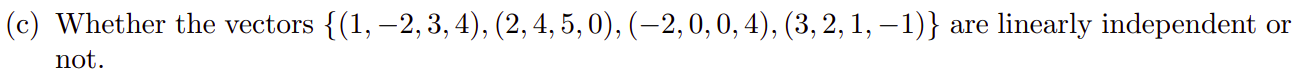

In [232]:
v_c1 = [1, -2, 3, 4]
v_c2 = [2, 4, 5, 0]
v_c3 = [-2, 0, 0, 4]
v_c4 = [3, 2, 1, -1]
C = np.column_stack((v_c1, v_c2,v_c3,v_c4))
print(f"Câu (c): {is_linear_independent(C)}")

Câu (c): True


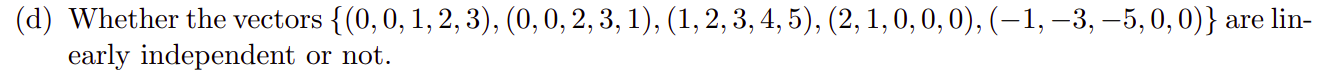

In [233]:
v_d1 = [0, 0, 1, 2, 3]
v_d2 = [0, 0, 2, 3, 1]
v_d3 = [1, 2, 3, 4, 5]
v_d4 = [2, 1, 0, 0, 0]
v_d5 = [-1, -3, -5, 0, 0]
C = np.column_stack((v_d1,v_d2,v_d3,v_d4,v_d5))
print(f"Câu (d): {is_linear_independent(C)}")

Câu (d): True


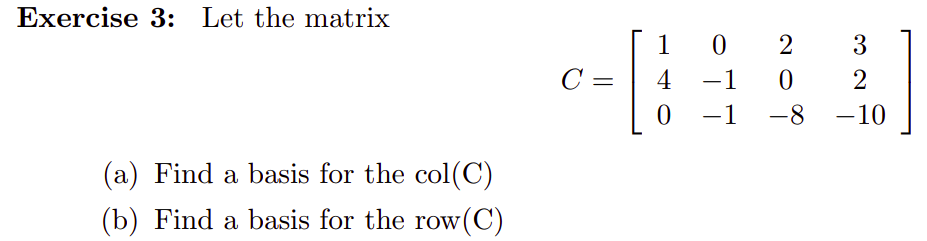

In [234]:
def find_row_space(C):
    R, pivot_index = C.rref()
    for i in range (len(pivot_index)):
        print(R.row(i))
def find_col_space(C):
    R, pivot_index = C.rref()
    # print(R)

    for i in range (len(pivot_index)):
        print(C.col(i))
        

In [235]:
C = sp.Matrix([[1,0,2,3],[4,-1,0,2],[0,-1,-8.,-10]])
print("Cau a:")
find_col_space(C)
print("Cau b:")
find_row_space(C)

Cau a:
Matrix([[1], [4], [0]])
Matrix([[0], [-1], [-1]])
Cau b:
Matrix([[1, 0, 2, 3]])
Matrix([[0, 1, 8, 10]])


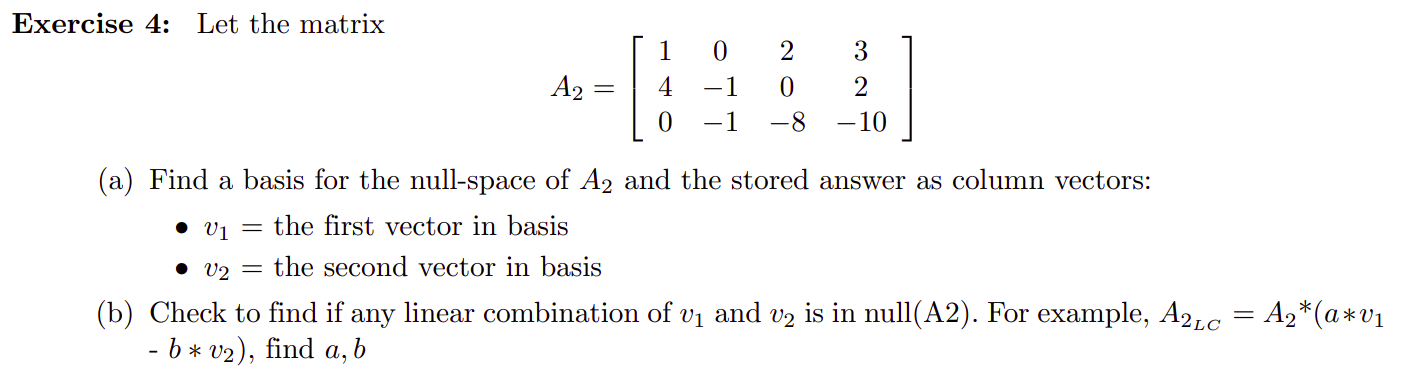

In [236]:
A2 = sp.Matrix([[1, 0, 2, 3], [4, -1, 0, 2], [0, -1, -8, -10]])
ns = A2.nullspace()
v1, v2 = ns[0], ns[1]
print(f"Cau 4(a): v1={v1}, v2={v2}")
a, b = 2, 3
lc = a*v1 + b*v2
print(f"Cau 4(b): {(A2 * lc).is_zero_matrix}")

Cau 4(a): v1=Matrix([[-2], [-8], [1], [0]]), v2=Matrix([[-3], [-10], [0], [1]])
Cau 4(b): True


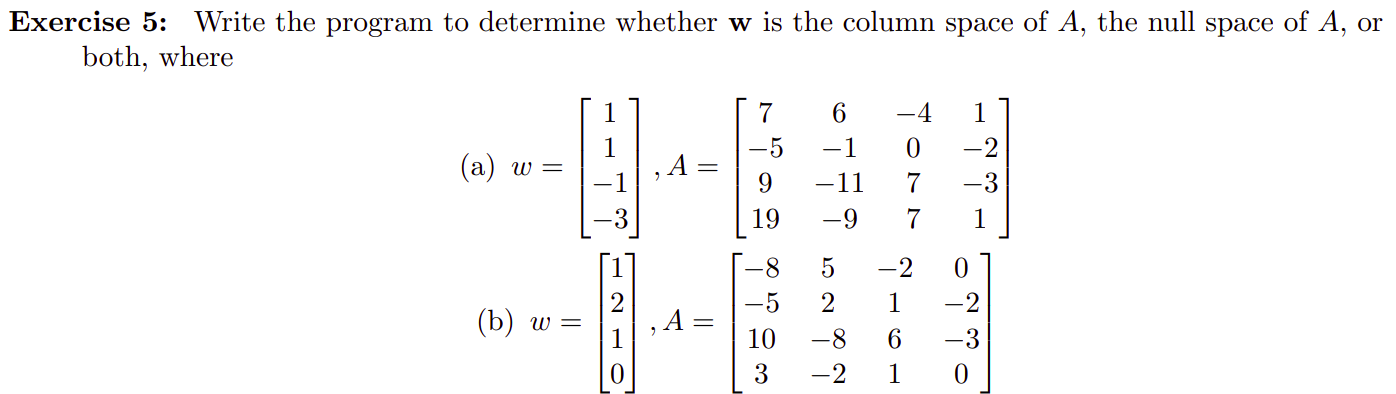

In [237]:
def check_w(A, w): 
    mat_A = sp.Matrix(A)
    mat_w = sp.Matrix(w)
    in_col = mat_A.rank() == mat_A.row_join(mat_w).rank()
    in_null = (mat_A * mat_w).is_zero_matrix if mat_A.cols == mat_w.rows else False
    return in_col, in_null

A_5a = [[-2, 1, 1], [-3, 7, 7], [1, 6, 6], [1, -5, -1]] 
w_5a = [-4, 17, 0, 7] 
print(f"Cau 5(a) (Col, Null): {check_w(A_5a, w_5a)}")

A_5b = [[-8, 5, -2, 0], [-5, 2, 1, -2], [10, -8, 6, -3], [3, -2, 1, 0]]
w_5b = [1, 2, 1, 0] 
print(f"Cau 5(b) (Col, Null): {check_w(A_5b, w_5b)}")

Cau 5(a) (Col, Null): (False, False)
Cau 5(b) (Col, Null): (True, True)


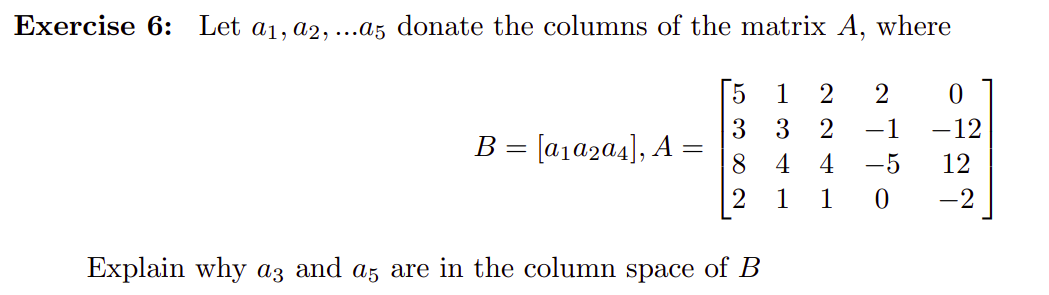

In [238]:
A6 = sp.Matrix([[5, 1, 2, 2, 0], [3, 3, 2, -1, -12], [8, 4, 4, -5, 12], [2, 1, 1, 0, -2]]) 
a1, a2, a3, a4, a5 = [A6.col(i) for i in range(5)]
B = sp.Matrix.hstack(a1, a2, a4) 
print(f"Cau 6 - a3 trong Col(B): {B.rank() == B.row_join(a3).rank()}") 
print(f"Cau 6 - a5 trong Col(B): {B.rank() == B.row_join(a5).rank()}")

Cau 6 - a3 trong Col(B): True
Cau 6 - a5 trong Col(B): True


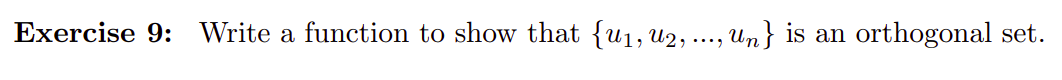

In [239]:
def is_orthogonal(set_v): 
    for i in range(len(set_v)):
        for j in range(i + 1, len(set_v)):
            if np.dot(set_v[i], set_v[j]) != 0: return False 
    return True
u1, u2, u3 = [3, 1, 1], [-1, 2, 1], [-0.5, 3.5, 3.5] 
print(f"Cau 9: {is_orthogonal([u1, u2, u3])}")

Cau 9: False


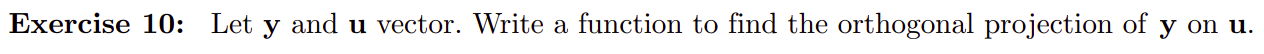

In [240]:
def ortho_proj(y, u): 
    y, u = np.array(y), np.array(u)
    return (np.dot(y, u) / np.dot(u, u)) * u 
print(f"Cau 10: {ortho_proj([7, 6], [4, 2])}") 

Cau 10: [8. 4.]


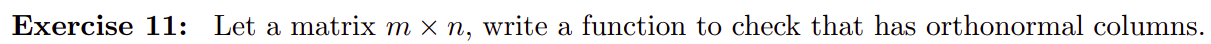

In [241]:
def is_orthonormal(U): 
    U = np.array(U)
    return np.allclose(U.T @ U, np.eye(U.shape[1]))
print(f"Cau 11: {is_orthonormal(np.eye(3))}")

Cau 11: True


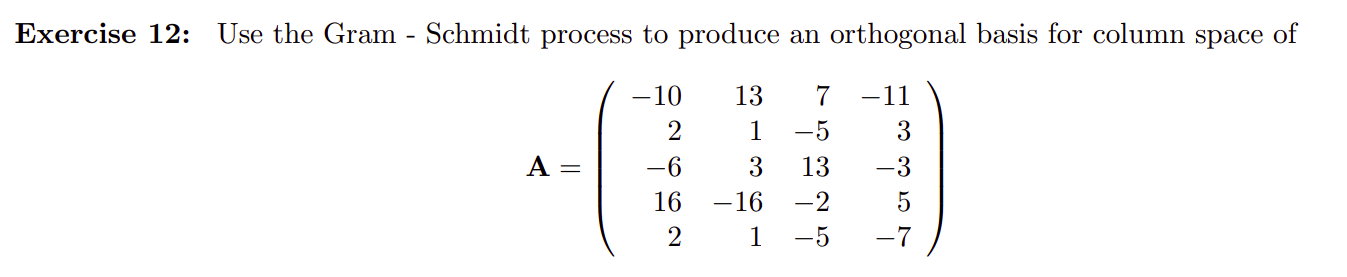

In [242]:
def gram_schmidt(A): 
    A = np.array(A, dtype=float)
    basis = []
    for i in range(A.shape[1]):
        v = A[:, i]
        for b in basis:
            v -= (np.dot(A[:, i], b) / np.dot(b, b)) * b
        if not np.allclose(v, 0): basis.append(v)
    return np.array(basis).T

A12 = [[-10, 13, 7, -11], [2, 1, -5, 3], [-6, 3, 13, -3], [16, -16, -2, 5], [2, 1, -5, -7]] 
print(f"Cau 12:\n{gram_schmidt(A12)}")

Cau 12:
[[-10.   3.   6.   0.]
 [  2.   3.   0.   5.]
 [ -6.  -3.   6.   0.]
 [ 16.   0.   6.   0.]
 [  2.   3.   0.  -5.]]
